# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset **tanpa label** dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.
   
2. **Ketentuan Dataset**:
   - **Tanpa label**: Dataset tidak boleh memiliki label atau kelas.
   - **Jumlah Baris**: Minimal 1000 baris untuk memastikan dataset cukup besar untuk analisis yang bermakna.
   - **Tipe Data**: Harus mengandung data **kategorikal** dan **numerikal**.
     - *Kategorikal*: Misalnya jenis kelamin, kategori produk.
     - *Numerikal*: Misalnya usia, pendapatan, harga.

3. **Pembatasan**:  
   Dataset yang sudah digunakan dalam latihan clustering (seperti customer segmentation) tidak boleh digunakan.

Dataset ini merupakan dataset kesehatan individu yang berisi informasi fisiologis dan gaya hidup. Dataset ini dapat digunakan untuk mengelompokkan individu berdasarkan profil kesehatan mereka, menganalisis faktor risiko penyakit kardiovaskular, atau mengembangkan model prediktif untuk klasifikasi kondisi kesehatan. Data ini kaya akan informasi metabolik dan gaya hidup, sehingga cocok untuk keperluan clustering, klasifikasi risiko, atau pemetaan gaya hidup sehat vs tidak sehat.

Dataset ini disusun untuk mensimulasikan data layanan kesehatan dunia nyata dengan tujuan memprediksi risiko seorang pasien mengidap penyakit kronis, seperti diabetes atau penyakit jantung. Dataset ini mengandung multikolinearitas, yang merupakan kejadian umum dalam data layanan kesehatan karena keterkaitan antar berbagai indikator kesehatan. Bisa dipastikan kolom Physical_Activity_Level **BUKAN** sebuah **LABEL**
https://www.kaggle.com/datasets/rajagrawal7089/healthcare/data


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from google.colab import drive
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
drive.mount('/content/drive')

Mounted at /content/drive


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

In [ ]:
df = pd.read_csv('Health.csv')
df.head()

,Unnamed: 0,Age,BMI,Systolic_BP,Diastolic_BP,Total_Cholesterol,HDL_Cholesterol,LDL_Cholesterol,Triglycerides,Smoking_Status,Physical_Activity_Level
0,0,69,20.716059,107.148438,58.251503,168.918511,38.417674,183.835062,243.341527,non-smoker,moderate
1,1,32,26.720231,102.948326,86.641598,203.912014,39.611571,209.084595,266.375424,smoker,high
2,2,89,25.971636,116.327033,90.282522,213.564817,39.406223,245.884831,256.974525,non-smoker,moderate
3,3,78,29.580788,104.273800,85.582392,204.301914,33.026881,207.493647,257.717821,non-smoker,moderate
4,4,38,28.353130,104.052584,81.326270,195.767143,34.558842,213.826737,246.513400,non-smoker,moderate


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset. EDA bertujuan untuk:

1. **Memahami Struktur Data**
   - Tinjau jumlah baris dan kolom dalam dataset.  
   - Tinjau jenis data di setiap kolom (numerikal atau kategorikal).

2. **Menangani Data yang Hilang**  
   - Identifikasi dan analisis data yang hilang (*missing values*). Tentukan langkah-langkah yang diperlukan untuk menangani data yang hilang, seperti pengisian atau penghapusan data tersebut.

3. **Analisis Distribusi dan Korelasi**  
   - Analisis distribusi variabel numerik dengan statistik deskriptif dan visualisasi seperti histogram atau boxplot.  
   - Periksa hubungan antara variabel menggunakan matriks korelasi atau scatter plot.

4. **Visualisasi Data**  
   - Buat visualisasi dasar seperti grafik distribusi dan diagram batang untuk variabel kategorikal.  
   - Gunakan heatmap atau pairplot untuk menganalisis korelasi antar variabel.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Mengambil hanya dua angka belakang koma

In [ ]:
float_columns = ['BMI', 'Systolic_BP', 'Diastolic_BP', 'Total_Cholesterol',
                 'HDL_Cholesterol', 'LDL_Cholesterol', 'Triglycerides']

df[float_columns] = df[float_columns].round(2)

BMI Category

Underweight: Less than 18.5

Healthy Weight: 18.5 to less than 25

Overweight: 25 to less than 30

Obesity: 30 or greater


In [ ]:
def showplot(df, column):
    count_data = df[column].value_counts()
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    plt.rcParams['font.family'] = 'Liberation Sans'

    colors = plt.cm.Paired.colors
    ax[0].pie(
        count_data.values, labels=None, autopct='%1.1f%%', startangle=90,
        colors=colors, pctdistance=0.85, wedgeprops=dict(width=0.3)
    )
    ax[0].set_title(f"Distribution of {column} (%)", fontname='Liberation Sans', fontsize=14, fontweight='bold')

    bars = ax[1].barh(count_data.index, count_data.values, color=colors)
    ax[1].set_title(f"{column} Count", fontname='Liberation Sans', fontsize=14, fontweight='bold')
    ax[1].set_xlabel("Count", fontname='Liberation Sans', fontsize=12)
    ax[1].invert_yaxis()

    for bar in bars:
        x_val = bar.get_width()
        y_val = bar.get_y() + bar.get_height() / 2
        ax[1].text(x_val - 50, y_val, f'{int(x_val)}', va='center', ha='right',
                   fontname='Liberation Sans', fontsize=12, fontweight='bold', color='white')

    ax[0].legend(count_data.index, loc="best", prop={'family': 'Liberation Sans', 'size': 10})

    plt.tight_layout()
    plt.show()

Sebaran Level Aktivitas

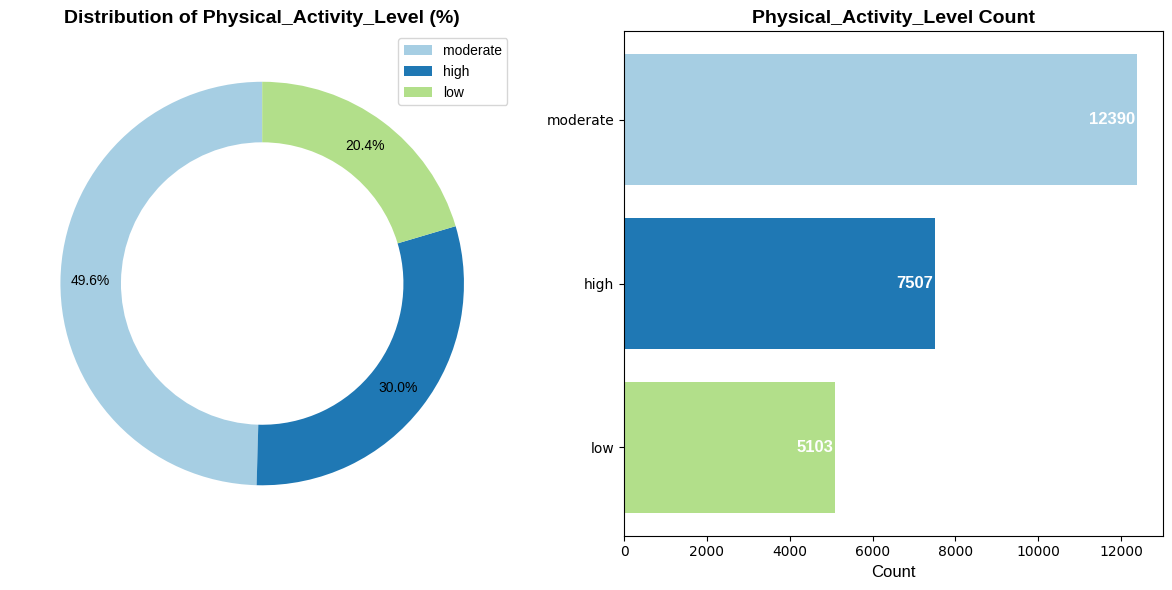

In [ ]:
showplot(df, 'Physical_Activity_Level')

Sebaran Perokok

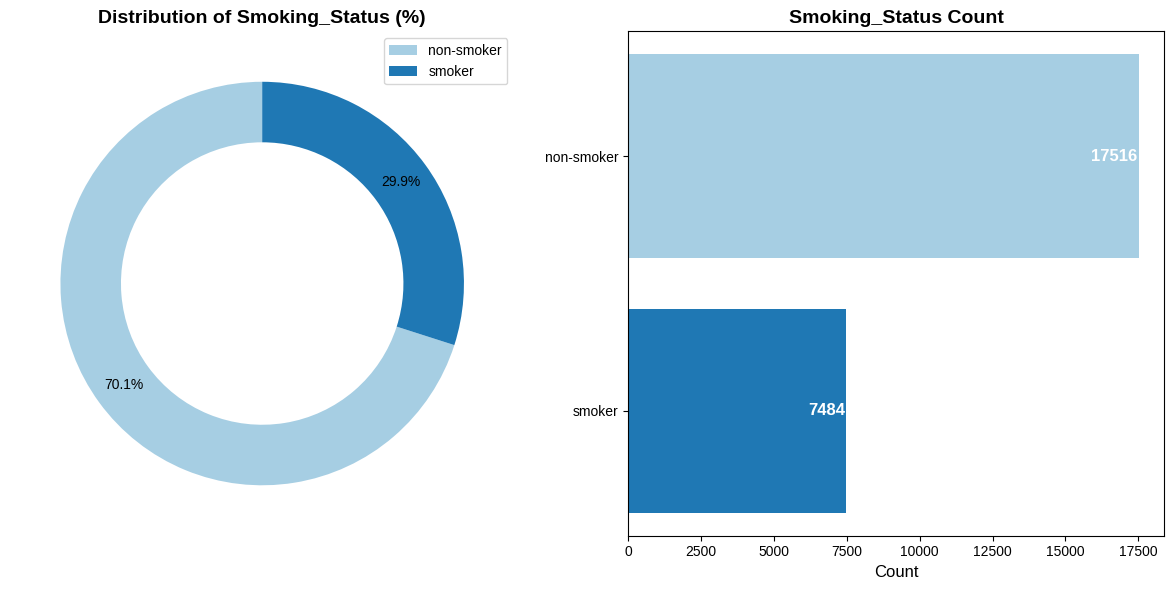

In [ ]:
showplot(df, 'Smoking_Status')

In [ ]:
df.describe()

,Unnamed: 0,Age,BMI,Systolic_BP,Diastolic_BP,Total_Cholesterol,HDL_Cholesterol,LDL_Cholesterol,Triglycerides
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,12499.500000,53.355360,27.009789,108.735002,81.750432,192.914694,37.351784,215.761970,248.809092
std,7217.022701,20.777743,5.020245,10.460681,8.368786,16.685220,5.030198,14.145902,21.795253
min,0.000000,18.000000,8.090000,70.270000,48.530000,126.720000,18.660000,151.190000,165.030000
25%,6249.750000,35.000000,23.620000,101.750000,76.100000,181.680000,34.000000,206.230000,234.147500
50%,12499.500000,53.000000,27.000000,108.790000,81.640000,192.955000,37.410000,215.805000,248.920000
75%,18749.250000,71.000000,30.400000,115.742500,87.390000,204.090000,40.720000,225.270000,263.392500
max,24999.000000,89.000000,46.690000,149.990000,112.230000,256.240000,58.070000,272.020000,332.200000


Sebaran/distribusi BMI

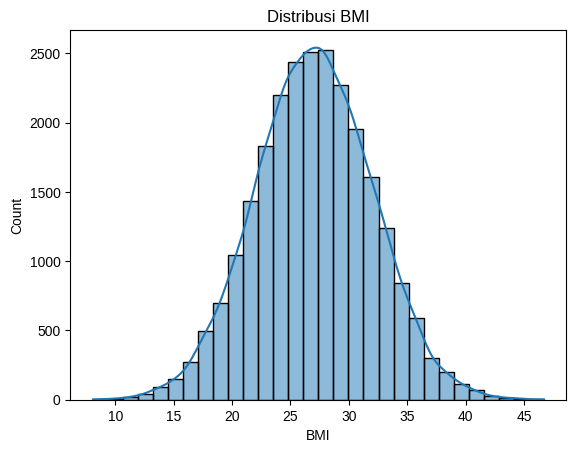

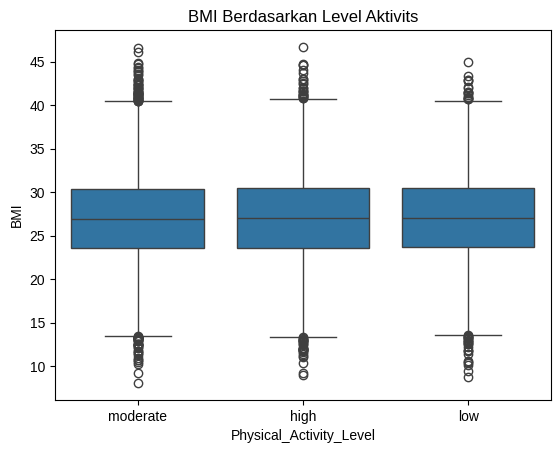

In [ ]:
sns.histplot(df['BMI'], kde=True, bins=30)
plt.title("Distribusi BMI")
plt.show()

sns.boxplot(x=df['Physical_Activity_Level'], y=df['BMI'])
plt.title("BMI Berdasarkan Level Aktivits")
plt.show()

Heatmap korelasi antar fitur

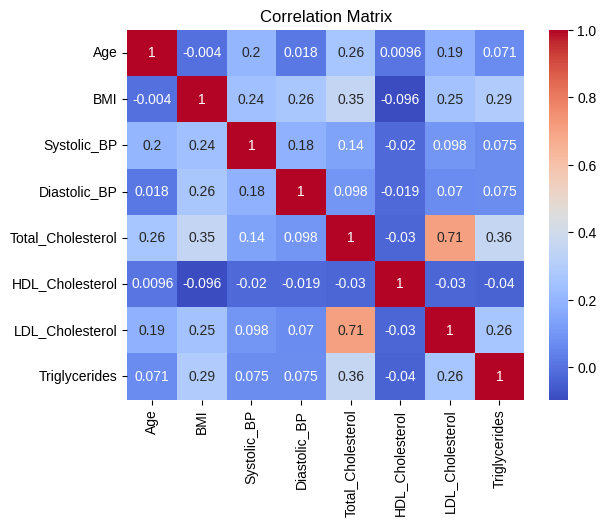


Correlation Matrix (Text Output):
                        BMI  Systolic_BP  Diastolic_BP  Total_Cholesterol  \
BMI                1.000000     0.238105      0.264897           0.353670   
Systolic_BP        0.238105     1.000000      0.183009           0.138506   
Diastolic_BP       0.264897     0.183009      1.000000           0.098087   
Total_Cholesterol  0.353670     0.138506      0.098087           1.000000   
HDL_Cholesterol   -0.095780    -0.019747     -0.019389          -0.030404   
LDL_Cholesterol    0.248449     0.097969      0.070127           0.706810   
Triglycerides      0.292009     0.075129      0.074810           0.360313   

                   HDL_Cholesterol  LDL_Cholesterol  Triglycerides  
BMI                      -0.095780         0.248449       0.292009  
Systolic_BP              -0.019747         0.097969       0.075129  
Diastolic_BP             -0.019389         0.070127       0.074810  
Total_Cholesterol        -0.030404         0.706810       0.360313  
HDL

In [ ]:
xx_columns = ['Age','BMI', 'Systolic_BP', 'Diastolic_BP', 'Total_Cholesterol',
             'HDL_Cholesterol', 'LDL_Cholesterol', 'Triglycerides']
sns.heatmap(df[xx_columns].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

print("\nCorrelation Matrix (Text Output):")
print(df[float_columns].corr())

Perbandingan BMI dan body fat berdasarkan usia

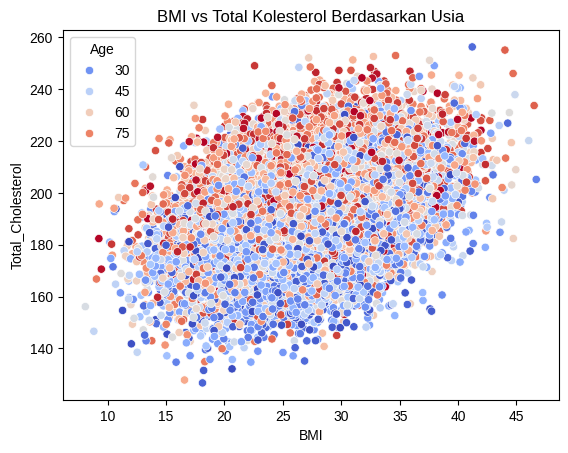

In [ ]:
sns.scatterplot(x=df['BMI'], y=df['Total_Cholesterol'], hue=df['Age'], palette='coolwarm')
plt.title("BMI vs Total Kolesterol Berdasarkan Usia")
plt.show()

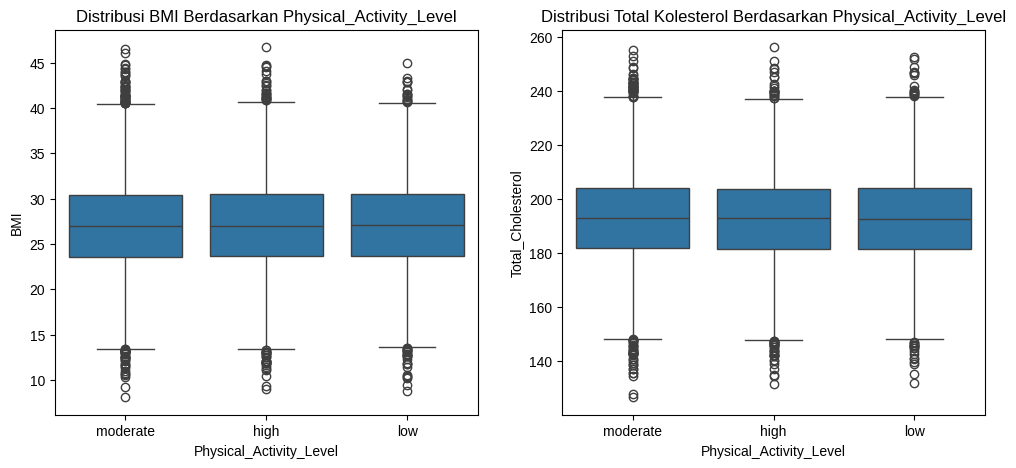

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.boxplot(x=df['Physical_Activity_Level'], y=df['BMI'], ax=ax[0])
ax[0].set_title("Distribusi BMI Berdasarkan Physical_Activity_Level")

sns.boxplot(x=df['Physical_Activity_Level'], y=df['Total_Cholesterol'], ax=ax[1])
ax[1].set_title("Distribusi Total Kolesterol Berdasarkan Physical_Activity_Level")

plt.show()

Plotting antara age, bmi, dan body fat untuk melihat persebarannya

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable h

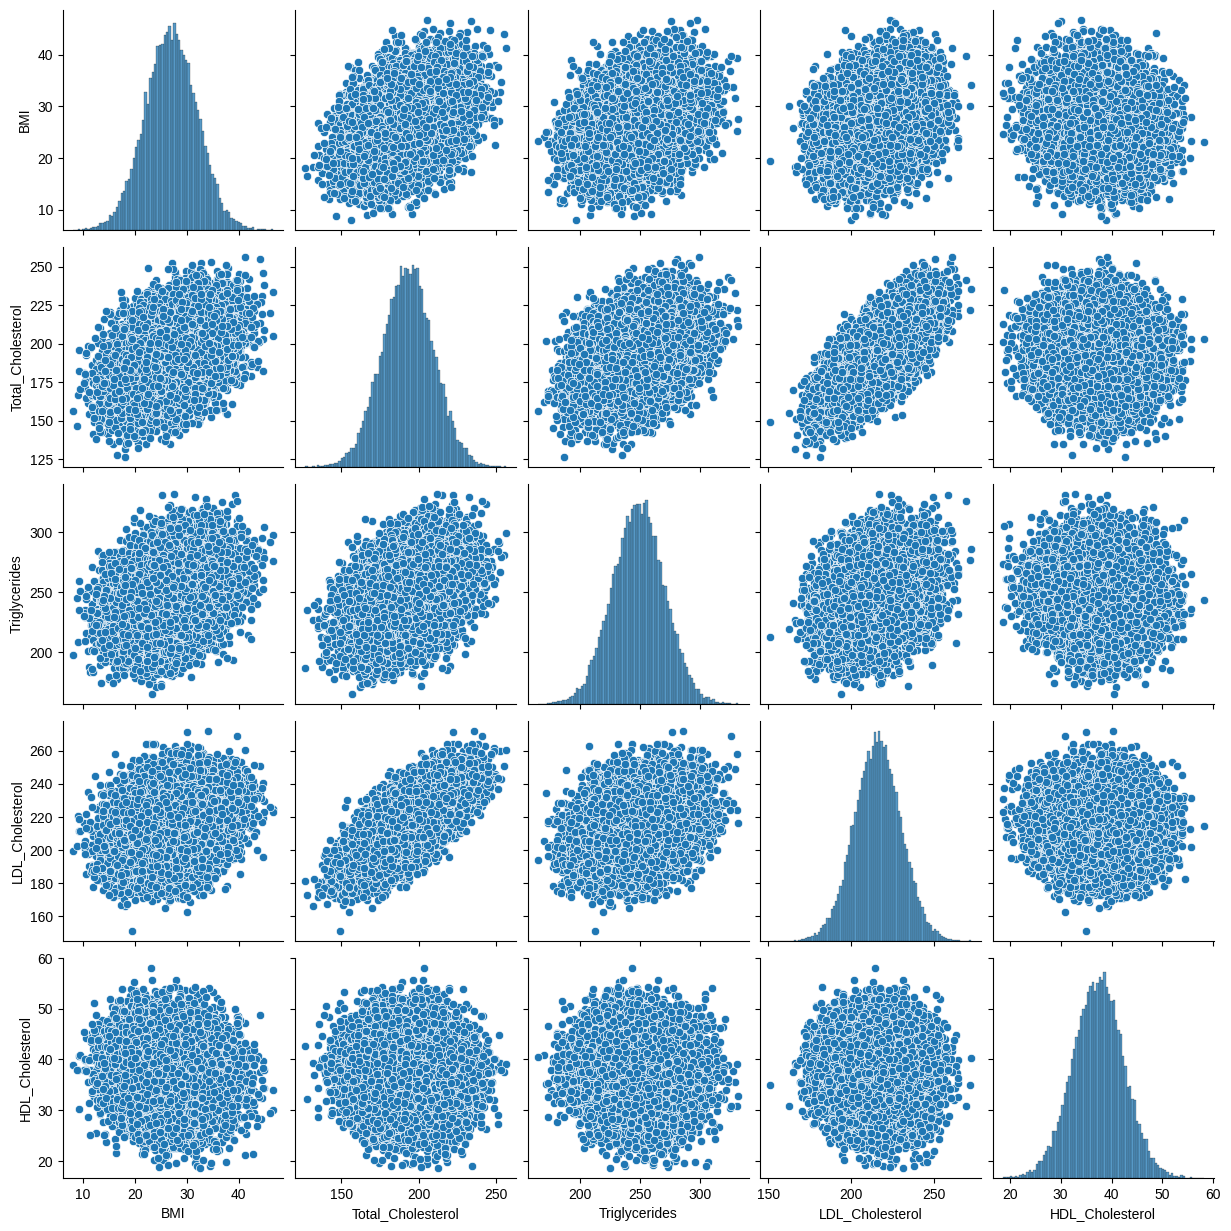

In [ ]:
sns.pairplot(df[['BMI', 'Total_Cholesterol', 'Triglycerides','LDL_Cholesterol','HDL_Cholesterol']], palette='coolwarm')
plt.show()

Melihat distribusi untuk kolom numerik

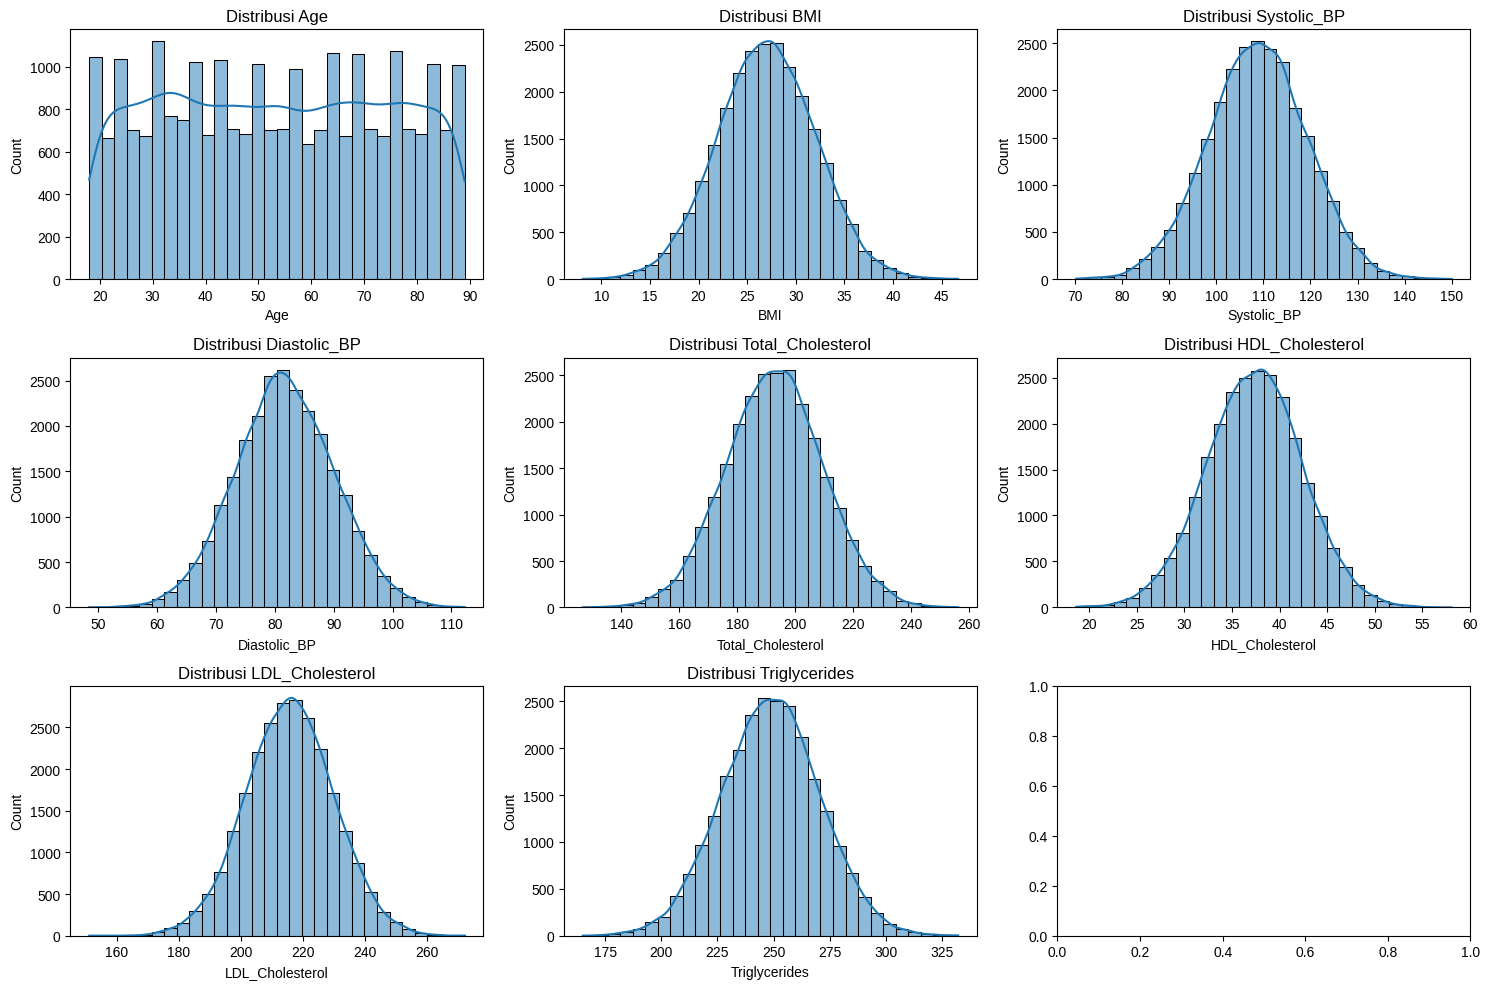

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))

for i, col in enumerate(df[xx_columns]):
    row, col_idx = divmod(i, 3)
    sns.histplot(df[col], bins=30, kde=True, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f"Distribusi {col}")

plt.tight_layout()
plt.show()

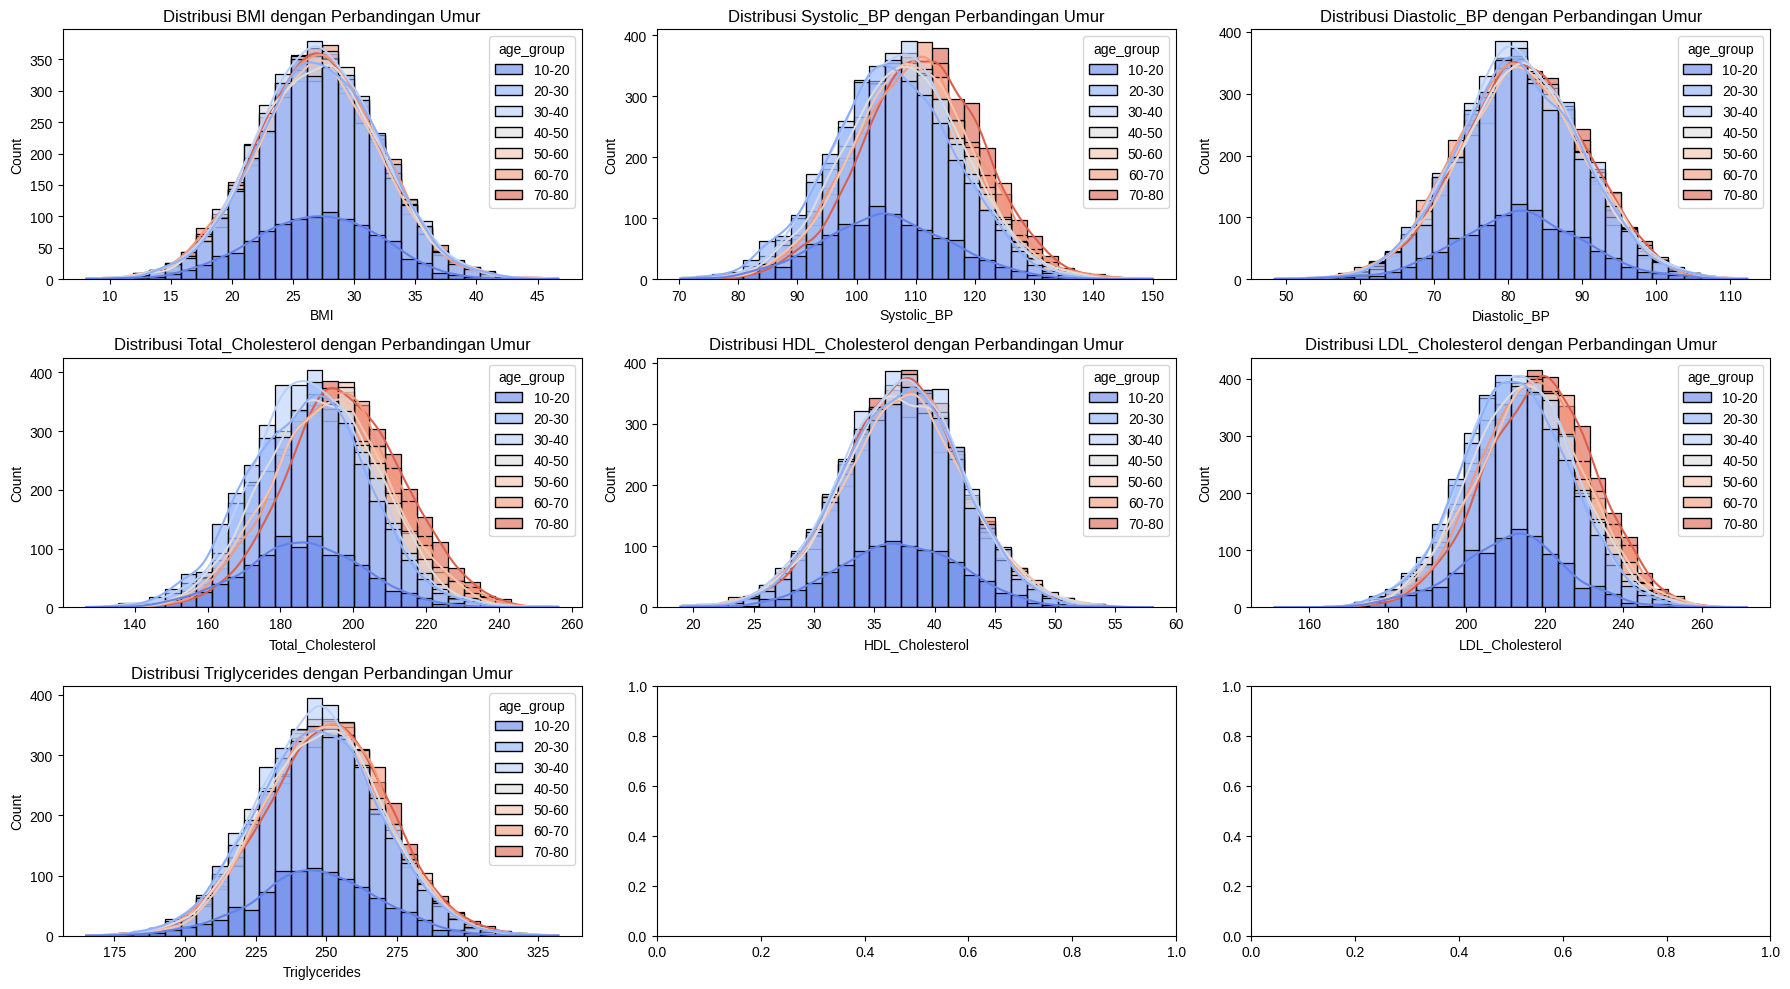

In [ ]:
# Berdasarkan umur
df_xx = df.copy()
df_xx['age_group'] = pd.cut(df_xx['Age'], bins=[10, 20, 30, 40, 50, 60, 70, 80], labels=['10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80'])

fig, axes = plt.subplots(3, 3, figsize=(18, 10))

for i, col in enumerate(df[float_columns]):
    row, col_idx = divmod(i, 3)
    sns.histplot(data=df_xx, x=col, hue="age_group", bins=30, kde=True, ax=axes[row, col_idx], palette="coolwarm", alpha=0.6)
    axes[row, col_idx].set_title(f"Distribusi {col} dengan Perbandingan Umur")

plt.tight_layout()
plt.show()

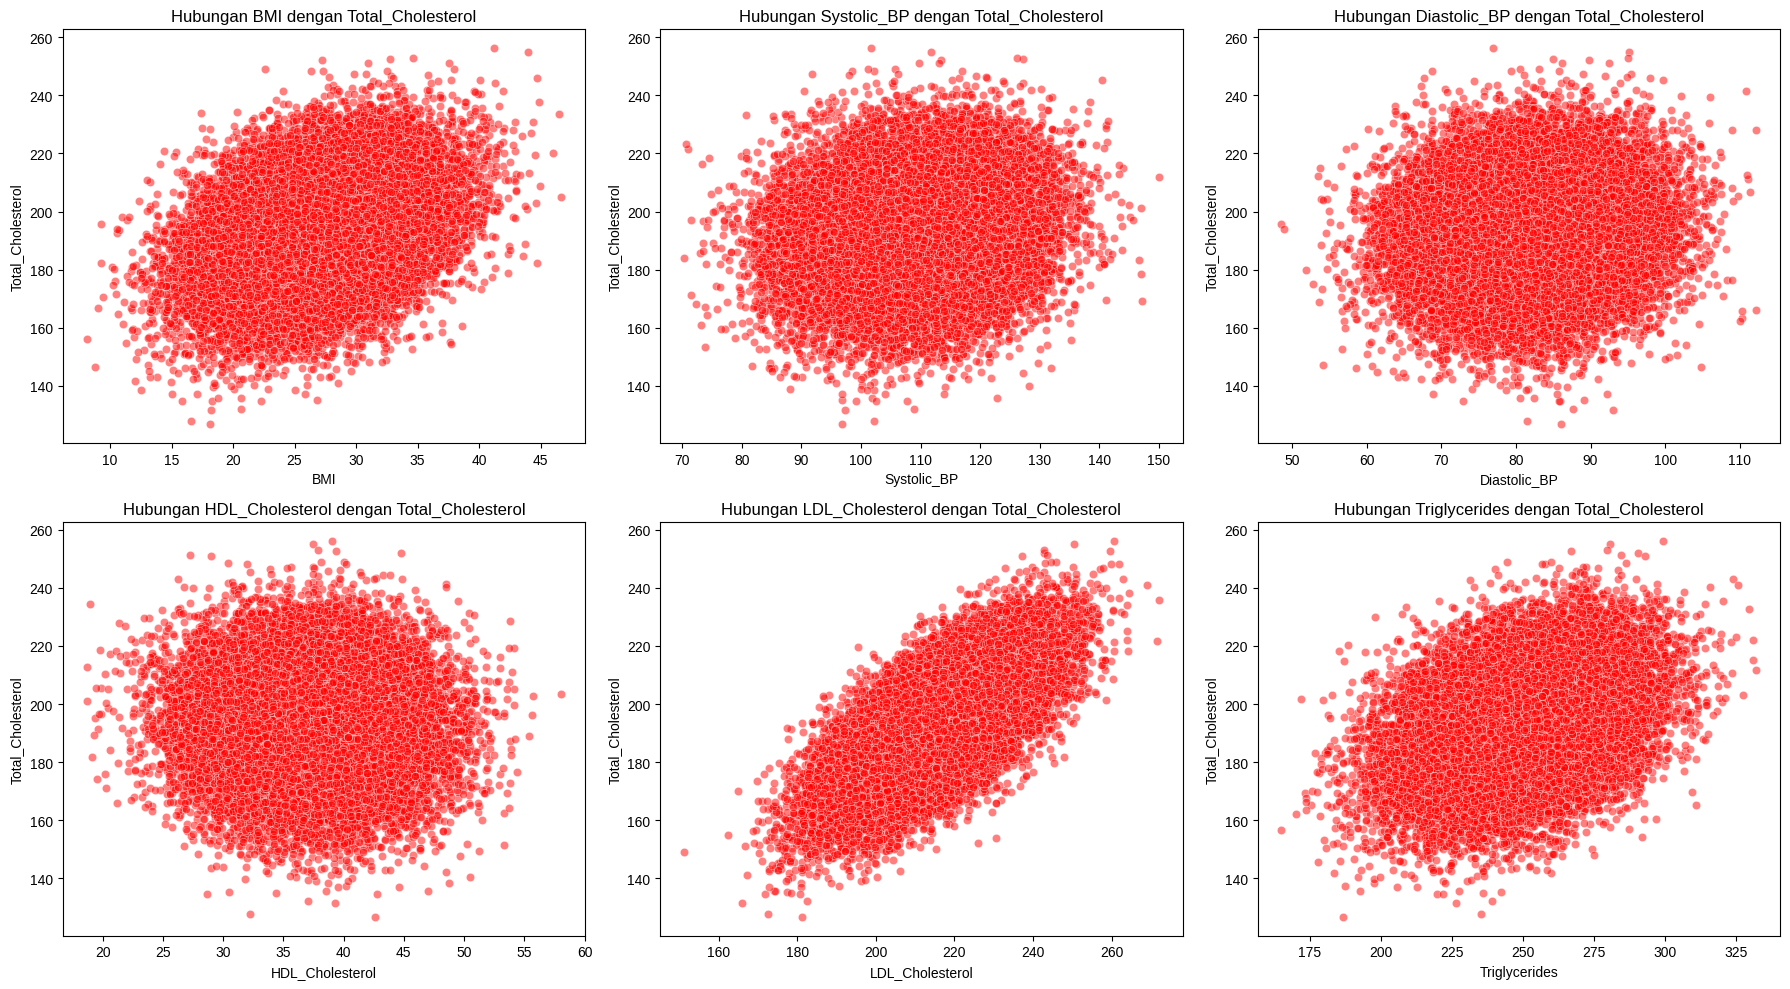

In [ ]:
#Berdasarkan total kolesterol

col_to_plot = ['BMI', 'Systolic_BP', 'Diastolic_BP', 'HDL_Cholesterol', 'LDL_Cholesterol', 'Triglycerides']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(col_to_plot):
    row, col_idx = divmod(i, 3)
    sns.scatterplot(x=df[col], y=df['Total_Cholesterol'], alpha=0.5, ax=axes[row, col_idx], color="red")
    axes[row, col_idx].set_title(f"Hubungan {col} dengan Total_Cholesterol")
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel("Total_Cholesterol")

plt.tight_layout()
plt.show()

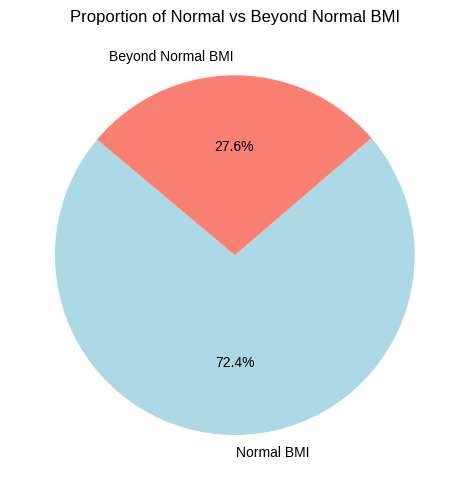

In [ ]:
beyond_normal_bmi = len(df[df['BMI'] > 30])
beyond_normal_bmi

total_people = len(df)

beyond_normal_bmi = len(df[df['BMI'] > 30])
normal_bmi = total_people - beyond_normal_bmi


labels = ['Normal BMI', 'Beyond Normal BMI']
sizes = [normal_bmi, beyond_normal_bmi]
colors = ['lightblue', 'salmon']

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title("Proportion of Normal vs Beyond Normal BMI")

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning. Data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah.

In [ ]:
df.head()

,Unnamed: 0,Age,BMI,Systolic_BP,Diastolic_BP,Total_Cholesterol,HDL_Cholesterol,LDL_Cholesterol,Triglycerides,Smoking_Status,Physical_Activity_Level
0,0,69,20.72,107.15,58.25,168.92,38.42,183.84,243.34,non-smoker,moderate
1,1,32,26.72,102.95,86.64,203.91,39.61,209.08,266.38,smoker,high
2,2,89,25.97,116.33,90.28,213.56,39.41,245.88,256.97,non-smoker,moderate
3,3,78,29.58,104.27,85.58,204.30,33.03,207.49,257.72,non-smoker,moderate
4,4,38,28.35,104.05,81.33,195.77,34.56,213.83,246.51,non-smoker,moderate


In [ ]:
df = df.drop('Unnamed: 0', axis = 1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      25000 non-null  int64  
 1   BMI                      25000 non-null  float64
 2   Systolic_BP              25000 non-null  float64
 3   Diastolic_BP             25000 non-null  float64
 4   Total_Cholesterol        25000 non-null  float64
 5   HDL_Cholesterol          25000 non-null  float64
 6   LDL_Cholesterol          25000 non-null  float64
 7   Triglycerides            25000 non-null  float64
 8   Smoking_Status           25000 non-null  object 
 9   Physical_Activity_Level  25000 non-null  object 
dtypes: float64(7), int64(1), object(2)
memory usage: 1.9+ MB


In [ ]:
df['Smoking_Status'] = df['Smoking_Status'].map({'non-smoker': 0, 'smoker': 1})
df['Physical_Activity_Level'] = df['Physical_Activity_Level'].map({'low': 0, 'moderate': 1, 'high': 2})
df.head()

,Age,BMI,Systolic_BP,Diastolic_BP,Total_Cholesterol,HDL_Cholesterol,LDL_Cholesterol,Triglycerides,Smoking_Status,Physical_Activity_Level
0,69,20.72,107.15,58.25,168.92,38.42,183.84,243.34,0,1
1,32,26.72,102.95,86.64,203.91,39.61,209.08,266.38,1,2
2,89,25.97,116.33,90.28,213.56,39.41,245.88,256.97,0,1
3,78,29.58,104.27,85.58,204.30,33.03,207.49,257.72,0,1
4,38,28.35,104.05,81.33,195.77,34.56,213.83,246.51,0,1


Seluruh DataFrame sudah dalam tipe data float

In [ ]:
df.describe()

,Age,BMI,Systolic_BP,Diastolic_BP,Total_Cholesterol,HDL_Cholesterol,LDL_Cholesterol,Triglycerides,Smoking_Status,Physical_Activity_Level
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,53.355360,27.009789,108.735002,81.750432,192.914694,37.351784,215.761970,248.809092,0.299360,1.096160
std,20.777743,5.020245,10.460681,8.368786,16.685220,5.030198,14.145902,21.795253,0.457987,0.703685
min,18.000000,8.090000,70.270000,48.530000,126.720000,18.660000,151.190000,165.030000,0.000000,0.000000
25%,35.000000,23.620000,101.750000,76.100000,181.680000,34.000000,206.230000,234.147500,0.000000,1.000000
50%,53.000000,27.000000,108.790000,81.640000,192.955000,37.410000,215.805000,248.920000,0.000000,1.000000
75%,71.000000,30.400000,115.742500,87.390000,204.090000,40.720000,225.270000,263.392500,1.000000,2.000000
max,89.000000,46.690000,149.990000,112.230000,256.240000,58.070000,272.020000,332.200000,1.000000,2.000000


In [ ]:
df = df.dropna()
df.isna().sum()

,0
Age,0
BMI,0
Systolic_BP,0
Diastolic_BP,0
Total_Cholesterol,0
HDL_Cholesterol,0
LDL_Cholesterol,0
Triglycerides,0
Smoking_Status,0
Physical_Activity_Level,0


Tidak ada data yang kosong

In [ ]:
df.duplicated().sum()

np.int64(0)

Tidak ada data yang duplikat

In [ ]:
features = ['BMI', 'LDL_Cholesterol', 'Triglycerides', 'Total_Cholesterol']
df_clustering = df[features]

print("Missing Values:\n", df_clustering.isnull().sum())

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clustering)

df_scaled = pd.DataFrame(df_scaled, columns=features)
df_scaled.head()


Missing Values:
 BMI                  0
LDL_Cholesterol      0
Triglycerides        0
Total_Cholesterol    0
dtype: int64


,BMI,LDL_Cholesterol,Triglycerides,Total_Cholesterol
0,-1.252910,-2.256668,-0.250935,-1.438110
1,-0.057725,-0.472370,0.806197,0.658998
2,-0.207123,2.129142,0.374443,1.237366
3,0.511979,-0.584773,0.408854,0.682372
4,0.266967,-0.136577,-0.105488,0.171131


# **6. Pembangunan Model Clustering**

## **a. Pembangunan Model Clustering**

Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan. Berikut adalah **rekomendasi** tahapannya.
1. Pilih algoritma clustering yang sesuai.
2. Latih model dengan data menggunakan algoritma tersebut.

Menggunakan algoritma clustering K-Means

In [ ]:
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=80)
df_scaled['Cluster'] = kmeans.fit_predict(df_scaled)

df['Cluster'] = df_scaled['Cluster']
df.head()


,Age,BMI,Systolic_BP,Diastolic_BP,Total_Cholesterol,HDL_Cholesterol,LDL_Cholesterol,Triglycerides,Smoking_Status,Physical_Activity_Level,Cluster
0,69,20.72,107.15,58.25,168.92,38.42,183.84,243.34,0,1,1
1,32,26.72,102.95,86.64,203.91,39.61,209.08,266.38,1,2,3
2,89,25.97,116.33,90.28,213.56,39.41,245.88,256.97,0,1,0
3,78,29.58,104.27,85.58,204.30,33.03,207.49,257.72,0,1,3
4,38,28.35,104.05,81.33,195.77,34.56,213.83,246.51,0,1,3


## **b. Evaluasi Model Clustering**

Untuk menentukan jumlah cluster yang optimal dalam model clustering, Anda dapat menggunakan metode Elbow atau Silhouette Score.

Metode ini membantu kita menemukan jumlah cluster yang memberikan pemisahan terbaik antar kelompok data, sehingga model yang dibangun dapat lebih efektif. Berikut adalah **rekomendasi** tahapannya.
1. Gunakan Silhouette Score dan Elbow Method untuk menentukan jumlah cluster optimal.
2. Hitung Silhouette Score sebagai ukuran kualitas cluster.

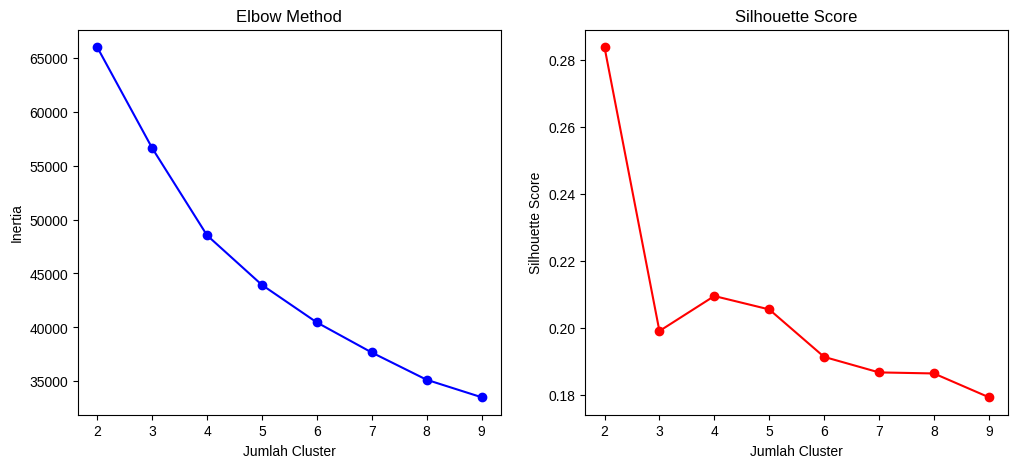

In [ ]:
inertia = []
silhouette_scores = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=100)
    kmeans.fit(df_scaled)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))

plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(K, inertia, 'bo-')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.subplot(1, 2, 2)
plt.plot(K, silhouette_scores, 'ro-')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')

plt.show()


Berdasarkan Elbow Method dan Silhouette Score, 4 cluster adalah jumlah cluster yang paling cocok

## **c. Feature Selection (Opsional)**

Silakan lakukan feature selection jika Anda membutuhkan optimasi model clustering. Jika Anda menerapkan proses ini, silakan lakukan pemodelan dan evaluasi kembali menggunakan kolom-kolom hasil feature selection. Terakhir, bandingkan hasil performa model sebelum dan sesudah menerapkan feature selection.

## **d. Visualisasi Hasil Clustering**

Setelah model clustering dilatih dan jumlah cluster optimal ditentukan, langkah selanjutnya adalah menampilkan hasil clustering melalui visualisasi.

Berikut adalah **rekomendasi** tahapannya.
1. Tampilkan hasil clustering dalam bentuk visualisasi, seperti grafik scatter plot atau 2D PCA projection.

Batas Normal

- **BMI**

Normal: 18.5 – 24.9
Overweight: 25–29.9
Obesitas: ≥30


- **Total_Cholesterol**

Ideal: < 200 mg/dL
Batas atas: 200–239
Tinggi: ≥240

- **HDL_Cholesterol (Kolesterol Baik)**

Pria: >40 mg/dL
Wanita: >50 mg/dL
Optimal: ≥60

- **LDL_Cholesterol (Kolesterol Jahat)**

Ideal: < 100 mg/dL
Borderline: 130–159
Tinggi: ≥160

- **Triglycerides**

Normal: < 150 mg/dL
Borderline: 150–199
Tinggi: ≥200

- **Systolic_BP (Tekanan darah atas)**

Ideal: < 120 mmHg
Prehypertension: 120–129
Hipertensi: ≥130

Tampilan semua fitur

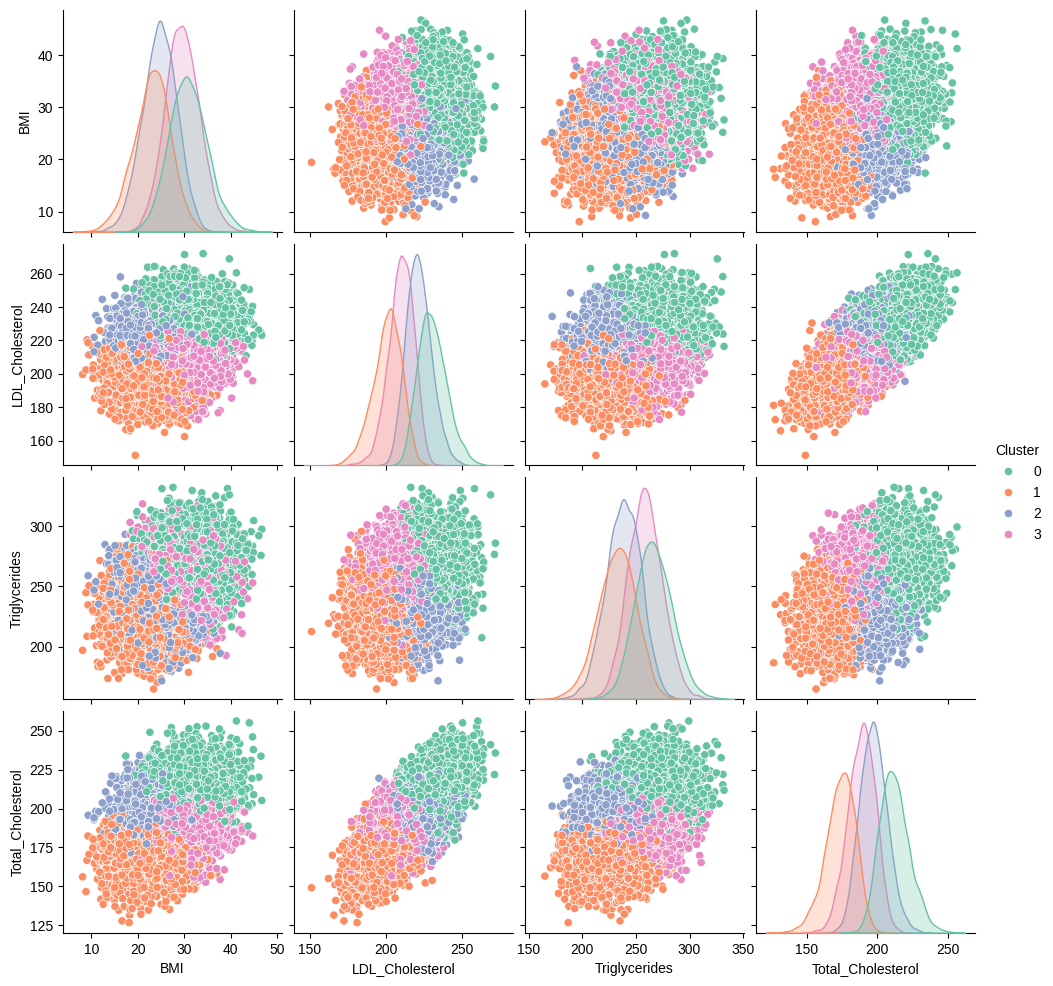

In [ ]:
df['Cluster'] = kmeans.labels_
sns.pairplot(df, vars=['BMI', 'LDL_Cholesterol', 'Triglycerides', 'Total_Cholesterol'], hue='Cluster', palette='Set2')
plt.show()

Visualisas clustering bmi dengan total kolesterol

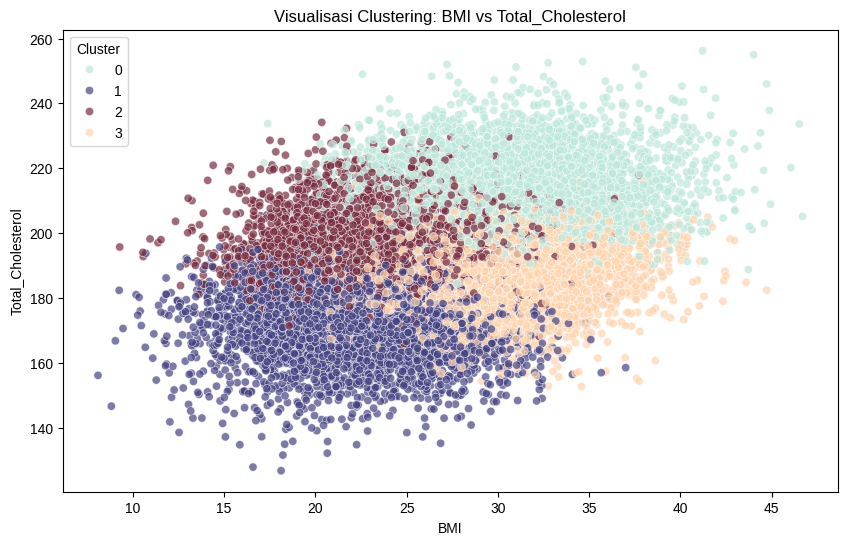

In [ ]:
x_col = 'BMI'
y_col = 'Total_Cholesterol'


plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x=x_col, y=y_col, hue='Cluster', palette='icefire', alpha=0.7)

plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title(f'Visualisasi Clustering: {x_col} vs {y_col}')
plt.legend(title="Cluster")

plt.show()


Visualisasi clustering BMI dan triglycerides

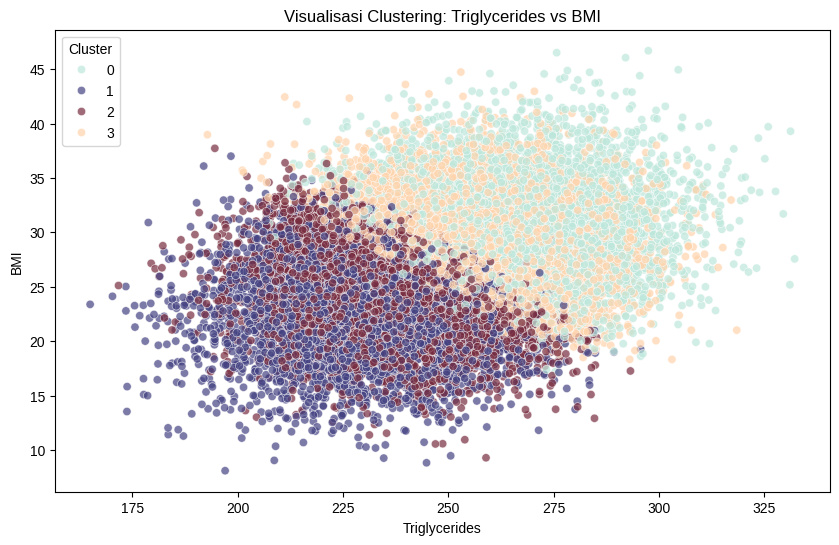

In [ ]:
y_col = 'BMI'
x_col = 'Triglycerides'


plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x=x_col, y=y_col, hue='Cluster', palette='icefire', alpha=0.7)

plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title(f'Visualisasi Clustering: {x_col} vs {y_col}')
plt.legend(title="Cluster")

plt.show()

Visualisasi bmi dan LDL kolesterol

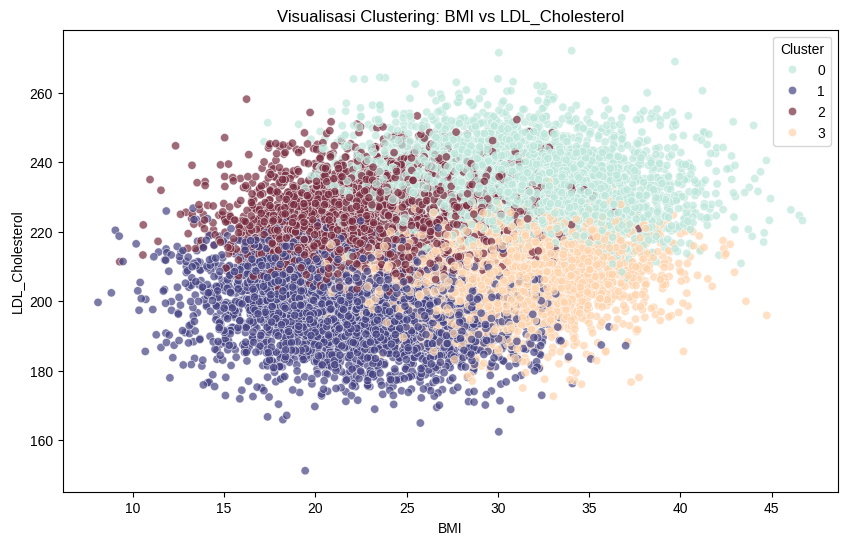

In [ ]:
x_col = 'BMI'
y_col = 'LDL_Cholesterol'


plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x=x_col, y=y_col, hue='Cluster', palette='icefire', alpha=0.7)

plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title(f'Visualisasi Clustering: {x_col} vs {y_col}')
plt.legend(title="Cluster")

plt.show()

## **e. Analisis dan Interpretasi Hasil Cluster**

### Interpretasi Target

**Tutorial: Melakukan Inverse Transform pada Data Target Setelah Clustering**

Setelah melakukan clustering dengan model **KMeans**, kita perlu mengembalikan data yang telah diubah (normalisasi, standarisasi, atau label encoding) ke bentuk aslinya. Berikut adalah langkah-langkahnya.

---

**1. Tambahkan Hasil Label Cluster ke DataFrame**
Setelah mendapatkan hasil clustering, kita tambahkan label cluster ke dalam DataFrame yang telah dinormalisasi.

```python
df_normalized['Cluster'] = model_kmeans.labels_
```

Lakukan Inverse Transform pada feature yang sudah dilakukan Labelisasi dan Standararisasi. Berikut code untuk melakukannya:
label_encoder.inverse_transform(X_Selected[['Fitur']])

Lalu masukkan ke dalam kolom dataset asli atau membuat dataframe baru
```python
df_normalized['Fitur'] = label_encoder.inverse_transform(df_normalized[['Fitur']])
```
Masukkan Data yang Sudah Di-Inverse ke dalam Dataset Asli atau Buat DataFrame Baru
```python
df_original['Fitur'] = df_normalized['Fitur']
```

Hasil label cluster sudah ditambahkan sebelumnya sekaligus proses modelling

In [ ]:
df

,Age,BMI,Systolic_BP,Diastolic_BP,Total_Cholesterol,HDL_Cholesterol,LDL_Cholesterol,Triglycerides,Smoking_Status,Physical_Activity_Level,Cluster
0,69,20.72,107.15,58.25,168.92,38.42,183.84,243.34,0,1,1
1,32,26.72,102.95,86.64,203.91,39.61,209.08,266.38,1,2,3
2,89,25.97,116.33,90.28,213.56,39.41,245.88,256.97,0,1,0
3,78,29.58,104.27,85.58,204.30,33.03,207.49,257.72,0,1,3
4,38,28.35,104.05,81.33,195.77,34.56,213.83,246.51,0,1,3
...,...,...,...,...,...,...,...,...,...,...,...
24995,87,15.98,129.52,93.01,177.30,40.23,199.20,229.35,0,1,1
24996,34,23.99,101.74,87.17,184.60,44.78,206.17,225.42,0,2,1
24997,27,26.73,101.74,87.02,166.87,41.85,221.07,224.64,0,1,1
24998,30,24.06,92.93,73.38,159.53,33.89,197.03,215.30,0,0,1


### Inverse Data Jika Melakukan Normalisasi/Standardisasi

Inverse Transform untuk Data yang Distandarisasi
Jika data numerik telah dinormalisasi menggunakan StandardScaler atau MinMaxScaler, kita bisa mengembalikannya ke skala asli:
```python
df_normalized[['Fitur_Numerik']] = scaler.inverse_transform(df_normalized[['Fitur_Numerik']])
```

DataFrame tetap dalam skala asli karena data yang telah distandarisasi disimpan di variable lain

In [ ]:
df

,Age,BMI,Systolic_BP,Diastolic_BP,Total_Cholesterol,HDL_Cholesterol,LDL_Cholesterol,Triglycerides,Smoking_Status,Physical_Activity_Level,Cluster
0,69,20.72,107.15,58.25,168.92,38.42,183.84,243.34,0,1,1
1,32,26.72,102.95,86.64,203.91,39.61,209.08,266.38,1,2,3
2,89,25.97,116.33,90.28,213.56,39.41,245.88,256.97,0,1,0
3,78,29.58,104.27,85.58,204.30,33.03,207.49,257.72,0,1,3
4,38,28.35,104.05,81.33,195.77,34.56,213.83,246.51,0,1,3
...,...,...,...,...,...,...,...,...,...,...,...
24995,87,15.98,129.52,93.01,177.30,40.23,199.20,229.35,0,1,1
24996,34,23.99,101.74,87.17,184.60,44.78,206.17,225.42,0,2,1
24997,27,26.73,101.74,87.02,166.87,41.85,221.07,224.64,0,1,1
24998,30,24.06,92.93,73.38,159.53,33.89,197.03,215.30,0,0,1


Setelah melakukan clustering, langkah selanjutnya adalah menganalisis karakteristik dari masing-masing cluster berdasarkan fitur yang tersedia.

Berikut adalah **rekomendasi** tahapannya.
1. Analisis karakteristik tiap cluster berdasarkan fitur yang tersedia (misalnya, distribusi nilai dalam cluster).
2. Berikan interpretasi: Apakah hasil clustering sesuai dengan ekspektasi dan logika bisnis? Apakah ada pola tertentu yang bisa dimanfaatkan?

In [ ]:
df.groupby('Cluster').mean()

,Age,BMI,Systolic_BP,Diastolic_BP,Total_Cholesterol,HDL_Cholesterol,LDL_Cholesterol,Triglycerides,Smoking_Status,Physical_Activity_Level
Cluster,,,,,,,,,,
0,58.927613,30.830325,111.076834,83.449361,212.099776,36.972910,230.737906,266.592313,0.294315,1.098870
1,47.802950,22.975403,106.217328,79.958884,173.642353,37.758229,200.635835,232.037962,0.290867,1.108742
2,56.314135,24.608910,107.915467,80.775564,197.198244,37.625169,221.708771,238.087294,0.311358,1.083906
3,50.362313,29.556815,109.683274,82.788612,188.618301,37.058823,209.882273,258.567586,0.298529,1.095821


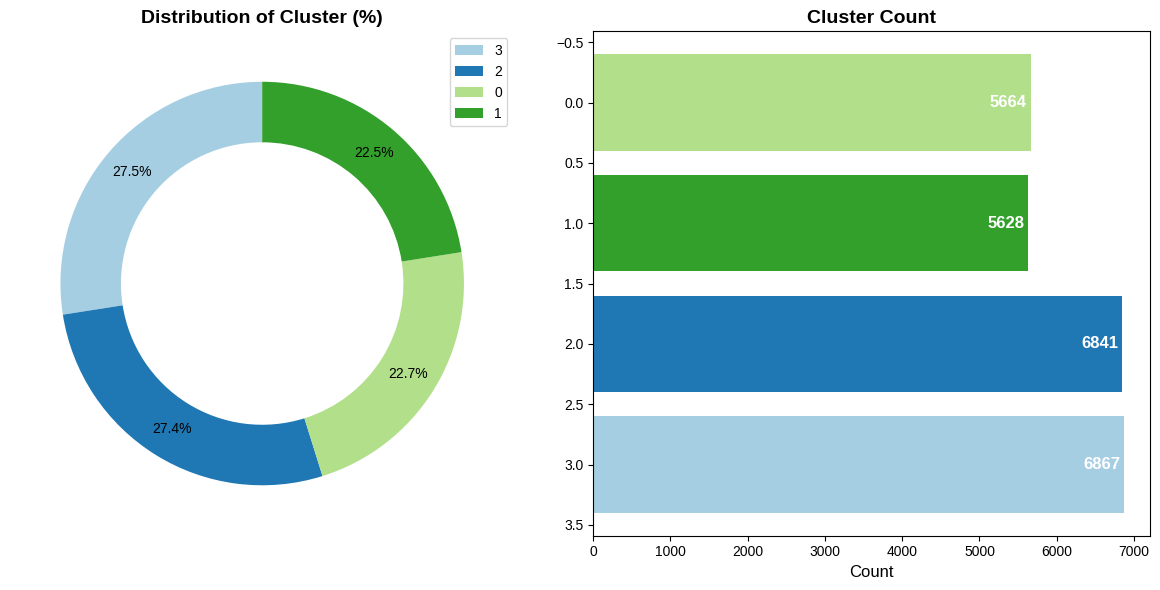

In [ ]:
showplot(df,'Cluster')

### Cluster 0 – Kelompok Paling Berisiko
Tertua (58.9 tahun), BMI tertinggi (30.8 = obesitas)

Kolesterol total tertinggi, LDL tertinggi, trigliserida tertinggi

HDL paling rendah (tidak protektif)

Aktivitas fisik dan merokok relatif sama dengan lainnya

Kesimpulan:

Cluster ini memiliki profil metabolik dan kardiovaskular terburuk. Potensi besar mengalami penyakit jantung, dan tekanan darah tinggi. Harus jadi prioritas untuk perbaikan gaya hidup & medis.


---

### Cluster 1 - Kelompok Paling Sehat
Usia termuda (47.8 tahun) dan BMI ideal (22.97)

Kolesterol total, LDL, trigliserida paling rendah

HDL tertinggi (walau selisih kecil)

Aktivitas fisik sedikit lebih tinggi

Kesimpulan:

Cluster ini adalah profil sehat secara umum. Risiko penyakit jantung relatif rendah. Ciri-ciri gaya hidup baik: berat badan ideal, profil lemak sehat.

---

### Cluster 2 – Kelompok Sehat Tapi Usia Lebih Tua
Usia hampir setara dengan Cluster 0 (56.3 tahun), tapi dengan:

BMI masih normal (24.6),

Kolesterol & LDL menengah,

Trigliserida lebih rendah dari cluster 0,3

HDL cukup baik

Kesimpulan:

Kondisi kesehatan baik namun sudah tua, jadi tetap perlu dimonitor. Bisa dikatakan sebagai kelompok sehat dengan risiko ringan karena usia.

---

### Cluster 3 – Overweight, Risiko Menengah
Usia menengah (50.4 tahun)

BMI tinggi (29.5 = overweight)

LDL dan Trigliserida cukup tinggi

HDL cukup rendah

Kesimpulan:

Risiko menengah. Bukan paling buruk, tapi BMI dan profil lipid menunjukkan kecenderungan menuju kelompok berisiko jika tidak ada intervensi.

---


Berdasarkan hasil clustering, didapatkan empat kelompok utama dengan karakteristik yang berbeda. Cluster 0 menggambarkan kelompok dengan risiko metabolik tertinggi, ditandai dengan usia lanjut, obesitas, kadar kolesterol jahat (LDL) dan trigliserida yang sangat tinggi, serta kadar HDL yang rendah. Sebaliknya, Cluster 1 menunjukkan kelompok paling sehat, dengan usia relatif muda, berat badan ideal, dan profil lipid yang baik. Cluster 2 terdiri dari individu dengan profil kesehatan yang baik namun berusia lebih tua, yang menandakan pentingnya pemantauan kesehatan pada usia lanjut meskipun dalam kondisi sehat. Sementara itu, Cluster 3 merepresentasikan kelompok dengan kelebihan berat badan dan profil lipid menengah, yang berpotensi berkembang menjadi kelompok berisiko tinggi apabila tidak ada intervensi gaya hidup. Hasil ini memberikan gambaran yang jelas bahwa pendekatan segmentasi berbasis clustering dapat membantu mengidentifikasi kelompok populasi yang memerlukan perhatian lebih dalam upaya pencegahan penyakit metabolik dan kardiovaskular.

# **7. Mengeksport Data**

Simpan hasilnya ke dalam file CSV.

In [ ]:
df.to_csv("Dataset_Inisiasi.csv", index = False)